In [77]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_path = '/content/drive/MyDrive/FF_Project'
if not os.path.exists(project_path):
    print(f"The folder '{project_path}' does not exist. Please check the path.")
else:
    os.chdir(project_path)
    print(f"Changed current working directory to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Changed current working directory to: /content/drive/MyDrive/FF_Project


In [78]:
import pandas as pd

file_name = 'Dataset.csv'

try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded '{file_name}'. Here are the first 5 rows:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the current directory: {os.getcwd()}")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded 'Dataset.csv'. Here are the first 5 rows:
            Transaction_Time         Open         High          Low  \
0  2026-04-06 00:20:00-04:00  6615.500000  6616.500000  6615.250000   
1  2026-04-06 00:20:00-04:00  4669.299805  4670.100098  4667.899902   
2  2026-04-06 00:21:00-04:00  6616.500000  6616.750000  6616.250000   
3  2026-04-06 00:21:00-04:00  4668.299805  4669.100098  4668.299805   
4  2026-04-06 00:22:00-04:00  4668.600098  4668.700195  4667.799805   

         Close  Volume Ticker  Log_Return  Volatility_20m  Price_Gap  \
0  6616.250000      54   ES=F    0.000113        0.000173   0.000000   
1  4668.000000      15   GC=F   -0.000150        0.000354   0.599609   
2  6616.750000      24   ES=F    0.000076        0.000161   0.250000   
3  4668.700195       7   GC=F    0.000150        0.000345   0.299805   
4  4667.799805      18   GC=F   -0.000193        0.000347  -0.100098   

     RSI_14m  Risk_Limit_USD  Entry_Price   Exit_Price   Trade_PnL  \
0  51.92

In [79]:
df

,Transaction_Time,Open,High,Low,Close,Volume,Ticker,Log_Return,Volatility_20m,Price_Gap,RSI_14m,Risk_Limit_USD,Entry_Price,Exit_Price,Trade_PnL,Slippage_USD,Cum_PnL,Peak,Drawdown
0,2026-04-06 00:20:00-04:00,6615.500000,6616.500000,6615.250000,6616.250000,54,ES=F,0.000113,0.000173,0.000000,51.923077,500,6615.500000,6616.250000,75.000000,0.325334,275.000000,475.000000,-200.000000
1,2026-04-06 00:20:00-04:00,4669.299805,4670.100098,4667.899902,4668.000000,15,GC=F,-0.000150,0.000354,0.599609,38.150207,500,4669.299805,4668.000000,-129.980469,0.325334,9.960938,819.970703,-810.009766
2,2026-04-06 00:21:00-04:00,6616.500000,6616.750000,6616.250000,6616.750000,24,ES=F,0.000076,0.000161,0.250000,59.183673,500,6616.500000,6616.750000,25.000000,0.112772,300.000000,475.000000,-175.000000
3,2026-04-06 00:21:00-04:00,4668.299805,4669.100098,4668.299805,4668.700195,7,GC=F,0.000150,0.000345,0.299805,47.403297,500,4668.299805,4668.700195,40.039062,0.112772,50.000000,819.970703,-769.970703
4,2026-04-06 00:22:00-04:00,4668.600098,4668.700195,4667.799805,4667.799805,18,GC=F,-0.000193,0.000347,-0.100098,41.558606,500,4668.600098,4667.799805,-80.029297,0.181465,-30.029297,819.970703,-850.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22952,2026-04-10 21:30:00+01:00,93.047997,93.047997,93.047997,93.047997,0,INR=X,0.000064,0.000060,0.005997,70.907325,500,93.047997,93.047997,0.000000,0.098907,1598.154449,1604.450989,-6.296539
22953,2026-04-10 21:31:00+01:00,93.049004,93.049004,93.049004,93.049004,0,INR=X,0.000011,0.000055,0.001007,70.911361,500,93.049004,93.049004,0.000000,0.491566,1598.154449,1604.450989,-6.296539
22954,2026-04-10 21:32:00+01:00,93.049004,93.050003,93.049004,93.050003,0,INR=X,0.000011,0.000054,0.000000,71.430518,500,93.049004,93.050003,0.099945,0.221727,1598.254395,1604.450989,-6.196594
22955,2026-04-10 21:33:00+01:00,93.049004,93.049004,93.047997,93.047997,0,INR=X,-0.000022,0.000055,-0.000999,72.718447,500,93.049004,93.047997,-0.100708,0.398856,1598.153687,1604.450989,-6.297302


### Data Cleaning: Initial Inspection and Type Conversion

In [80]:
# Display basic information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22957 entries, 0 to 22956
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_Time  22957 non-null  object 
 1   Open              22957 non-null  float64
 2   High              22957 non-null  float64
 3   Low               22957 non-null  float64
 4   Close             22957 non-null  float64
 5   Volume            22957 non-null  int64  
 6   Ticker            22957 non-null  object 
 7   Log_Return        22957 non-null  float64
 8   Volatility_20m    22957 non-null  float64
 9   Price_Gap         22957 non-null  float64
 10  RSI_14m           22957 non-null  float64
 11  Risk_Limit_USD    22957 non-null  int64  
 12  Entry_Price       22957 non-null  float64
 13  Exit_Price        22957 non-null  float64
 14  Trade_PnL         22957 non-null  float64
 15  Slippage_USD      22957 non-null  float64
 16  Cum_PnL           22957 non-null  float6

In [81]:
# Convert 'Transaction_Time' to datetime objects, explicitly handling timezones
df['Transaction_Time'] = pd.to_datetime(df['Transaction_Time'], utc=True)

# Verify the conversion by checking the data types again
print("Data types after converting 'Transaction_Time':")
print(df['Transaction_Time'].dtype)

# Display the first few rows to show the updated column
print("\nDataFrame head after Transaction_Time conversion:")
display(df.head())

Data types after converting 'Transaction_Time':
datetime64[ns, UTC]

DataFrame head after Transaction_Time conversion:


,Transaction_Time,Open,High,Low,Close,Volume,Ticker,Log_Return,Volatility_20m,Price_Gap,RSI_14m,Risk_Limit_USD,Entry_Price,Exit_Price,Trade_PnL,Slippage_USD,Cum_PnL,Peak,Drawdown
0,2026-04-06 04:20:00+00:00,6615.500000,6616.500000,6615.250000,6616.250000,54,ES=F,0.000113,0.000173,0.000000,51.923077,500,6615.500000,6616.250000,75.000000,0.325334,275.000000,475.000000,-200.000000
1,2026-04-06 04:20:00+00:00,4669.299805,4670.100098,4667.899902,4668.000000,15,GC=F,-0.000150,0.000354,0.599609,38.150207,500,4669.299805,4668.000000,-129.980469,0.325334,9.960938,819.970703,-810.009766
2,2026-04-06 04:21:00+00:00,6616.500000,6616.750000,6616.250000,6616.750000,24,ES=F,0.000076,0.000161,0.250000,59.183673,500,6616.500000,6616.750000,25.000000,0.112772,300.000000,475.000000,-175.000000
3,2026-04-06 04:21:00+00:00,4668.299805,4669.100098,4668.299805,4668.700195,7,GC=F,0.000150,0.000345,0.299805,47.403297,500,4668.299805,4668.700195,40.039062,0.112772,50.000000,819.970703,-769.970703
4,2026-04-06 04:22:00+00:00,4668.600098,4668.700195,4667.799805,4667.799805,18,GC=F,-0.000193,0.000347,-0.100098,41.558606,500,4668.600098,4667.799805,-80.029297,0.181465,-30.029297,819.970703,-850.000000


In [82]:
df.isnull().sum()

,0
Transaction_Time,0
Open,0
High,0
Low,0
Close,0
Volume,0
Ticker,0
Log_Return,0
Volatility_20m,0
Price_Gap,0


### Data Exploration: Unique Tickers

In [83]:
# Display unique values and their counts in the 'Ticker' column
print("Unique Tickers and their counts:")
print(df['Ticker'].value_counts())

Unique Tickers and their counts:
Ticker
GC=F     6502
ES=F     6480
ZN=F     6038
INR=X    3937
Name: count, dtype: int64


### Data Exploration: Transaction Time Range and Frequency

In [84]:
# Check the earliest and latest transaction times
earliest_time = df['Transaction_Time'].min()
latest_time = df['Transaction_Time'].max()

print(f"Earliest Transaction Time: {earliest_time}")
print(f"Latest Transaction Time: {latest_time}")

# Calculate the time difference to understand the frequency (assuming fairly regular intervals)
# We'll take the difference between consecutive timestamps and look at the most common difference
time_diffs = df['Transaction_Time'].diff().dropna()
most_common_frequency = time_diffs.value_counts().idxmax()

print(f"\nMost Common Time Frequency: {most_common_frequency}")

# Optionally, display a few unique time differences to see if there are other frequencies
# print("\nUnique Time Differences:")
# print(time_diffs.value_counts().head())


Earliest Transaction Time: 2026-04-06 01:14:00+00:00
Latest Transaction Time: 2026-04-10 21:01:00+00:00

Most Common Time Frequency: 0 days 00:00:00


### Data Exploration: Descriptive Statistics for Numerical Features

In [87]:
# Display descriptive statistics for all numerical columns
display(df.describe())

,Open,High,Low,Close,Volume,Log_Return,Volatility_20m,Price_Gap,RSI_14m,Risk_Limit_USD,Entry_Price,Exit_Price,Trade_PnL,Slippage_USD,Cum_PnL,Peak,Drawdown
count,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.0,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000,22957.000000
mean,3298.737196,3299.495960,3297.979127,3298.752684,720.001960,0.000003,0.000250,0.000160,50.423317,500.0,3298.737196,3298.752684,1.548721,0.273806,5829.296391,8471.265224,-2641.968832
std,2901.164500,2901.768042,2900.567691,2901.177659,1741.559596,0.000326,0.000210,0.327051,16.087242,0.0,2901.164500,2901.177659,156.706170,0.130193,7928.721241,9253.800333,3507.270509
min,92.190002,92.190002,92.190002,92.190002,0.000000,-0.004593,0.000013,-2.900391,0.000000,500.0,92.190002,92.190002,-3100.000000,0.050005,-5909.521484,0.000000,-15781.591800
25%,110.859375,110.875000,110.859375,110.859375,22.000000,-0.000128,0.000114,-0.015625,40.000000,500.0,110.859375,110.859375,-20.019531,0.160972,68.750000,109.375000,-5129.882813
50%,4691.600098,4693.000000,4689.799805,4691.500000,113.000000,0.000000,0.000173,0.000000,50.000000,500.0,4691.600098,4691.500000,0.000000,0.274500,1150.000000,4375.000000,-525.000000
75%,6623.500000,6625.000000,6622.250000,6623.500000,607.000000,0.000135,0.000326,0.015625,60.730848,500.0,6623.500000,6623.500000,20.019531,0.386424,11288.378910,17830.810550,-20.312500
max,6882.000000,6888.000000,6880.500000,6882.000000,62752.000000,0.008373,0.002097,25.500000,100.000000,500.0,6882.000000,6882.000000,4400.000000,0.499873,25150.000000,25150.000000,0.000000


### Data Exploration: Visualizing Numerical Feature Distributions

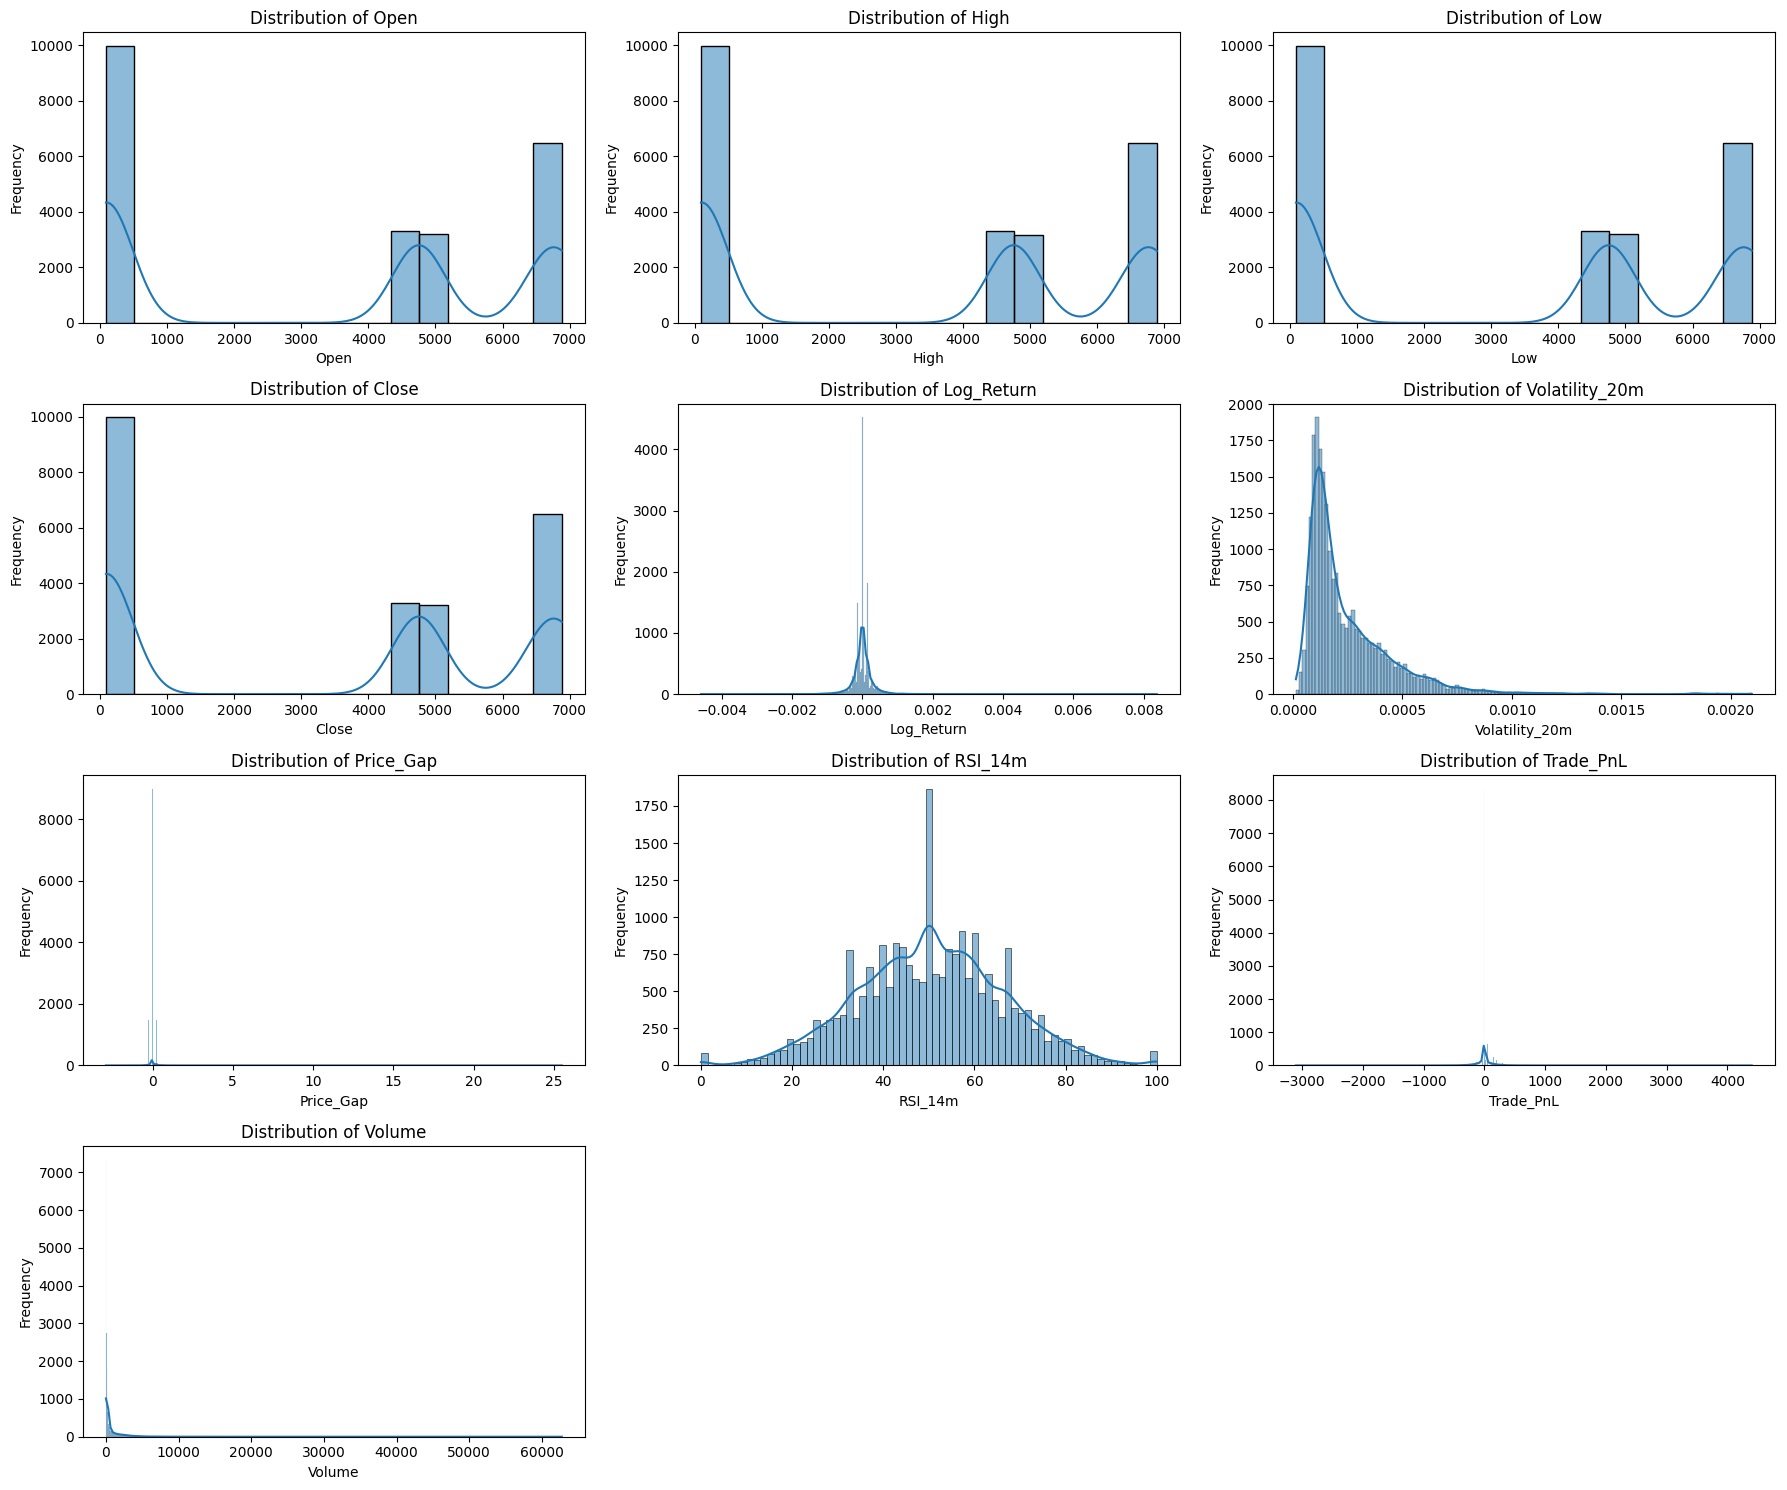

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for distribution visualization
numerical_cols = ['Open', 'High', 'Low', 'Close', 'Log_Return', 'Volatility_20m', 'Price_Gap', 'RSI_14m', 'Trade_PnL', 'Volume']

# Create histograms for selected numerical columns
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)  # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### Data Exploration: Correlation Matrix

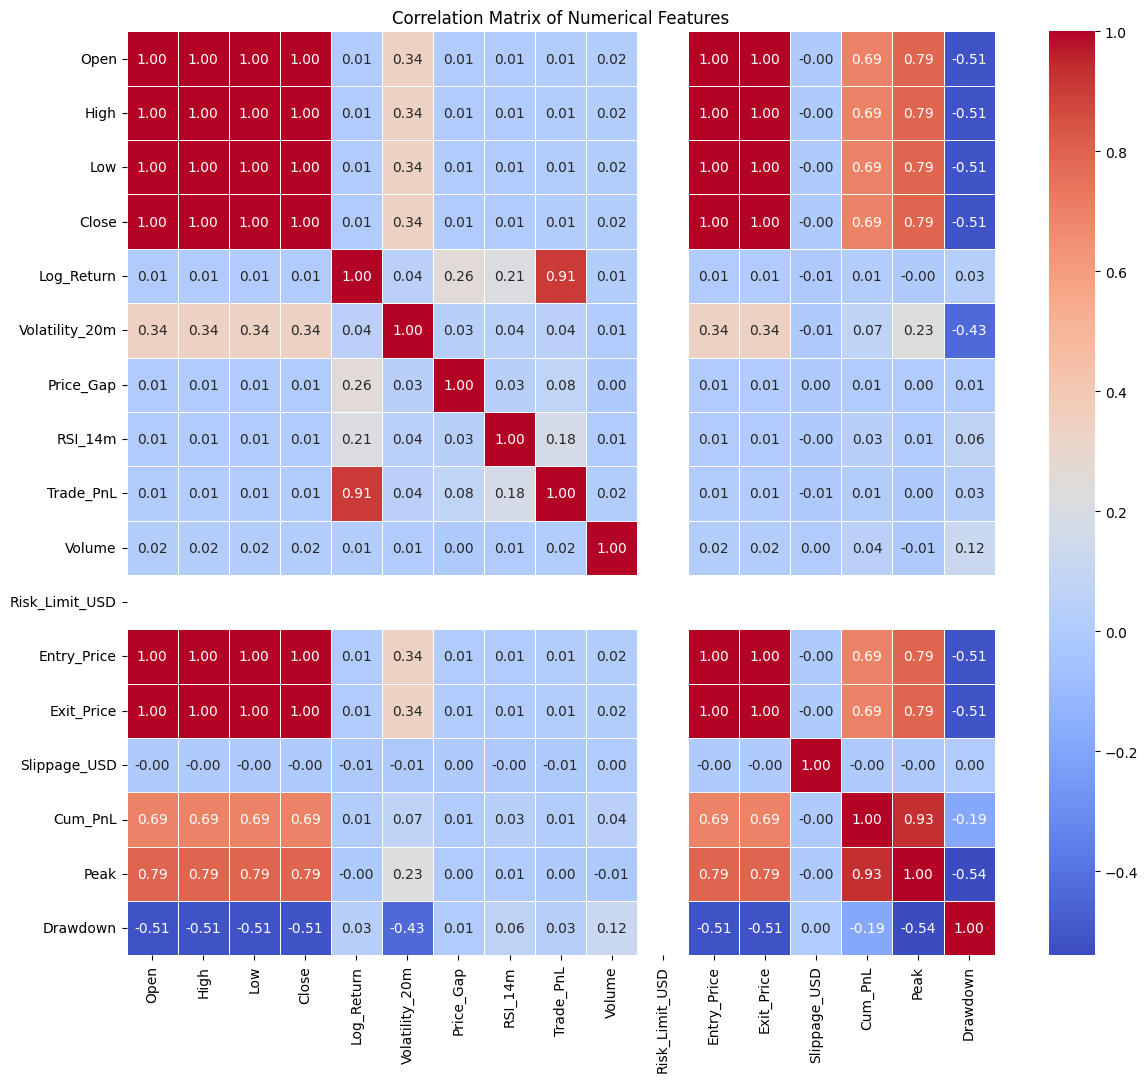

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation analysis (excluding ID-like or purely categorical represented as numbers)
numerical_cols_for_corr = ['Open', 'High', 'Low', 'Close', 'Log_Return', 'Volatility_20m', 'Price_Gap', 'RSI_14m', 'Trade_PnL', 'Volume', 'Risk_Limit_USD', 'Entry_Price', 'Exit_Price', 'Slippage_USD', 'Cum_PnL', 'Peak', 'Drawdown']

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols_for_corr].corr()

# Plot the correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Data Exploration: Ticker-wise Performance Analysis

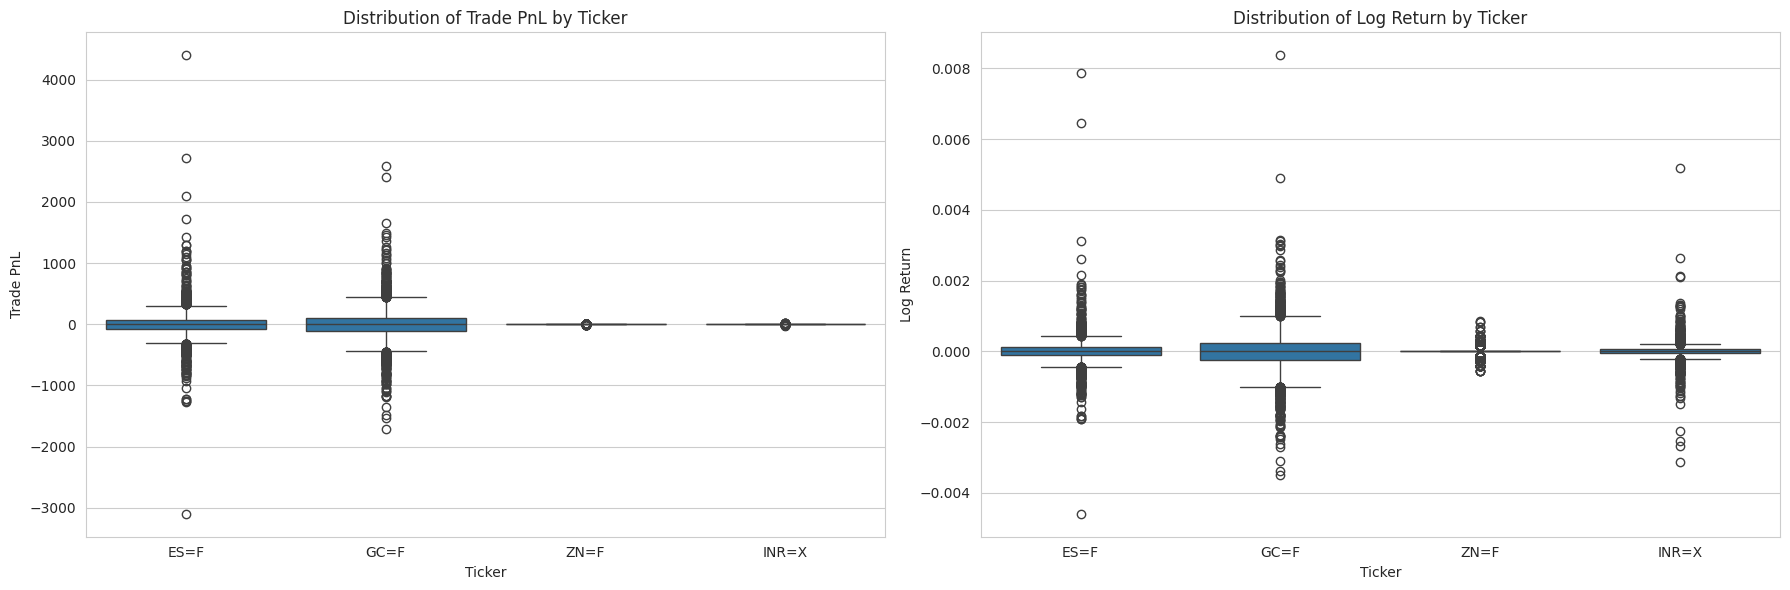

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Create subplots for Trade_PnL and Log_Return distributions per Ticker
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box plot for Trade_PnL by Ticker
sns.boxplot(x='Ticker', y='Trade_PnL', data=df, ax=axes[0])
axes[0].set_title('Distribution of Trade PnL by Ticker')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('Trade PnL')

# Box plot for Log_Return by Ticker
sns.boxplot(x='Ticker', y='Log_Return', data=df, ax=axes[1])
axes[1].set_title('Distribution of Log Return by Ticker')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Log Return')

plt.tight_layout()
plt.show()

### Data Exploration: Time-series Analysis of Cumulative PnL and Drawdown by Ticker

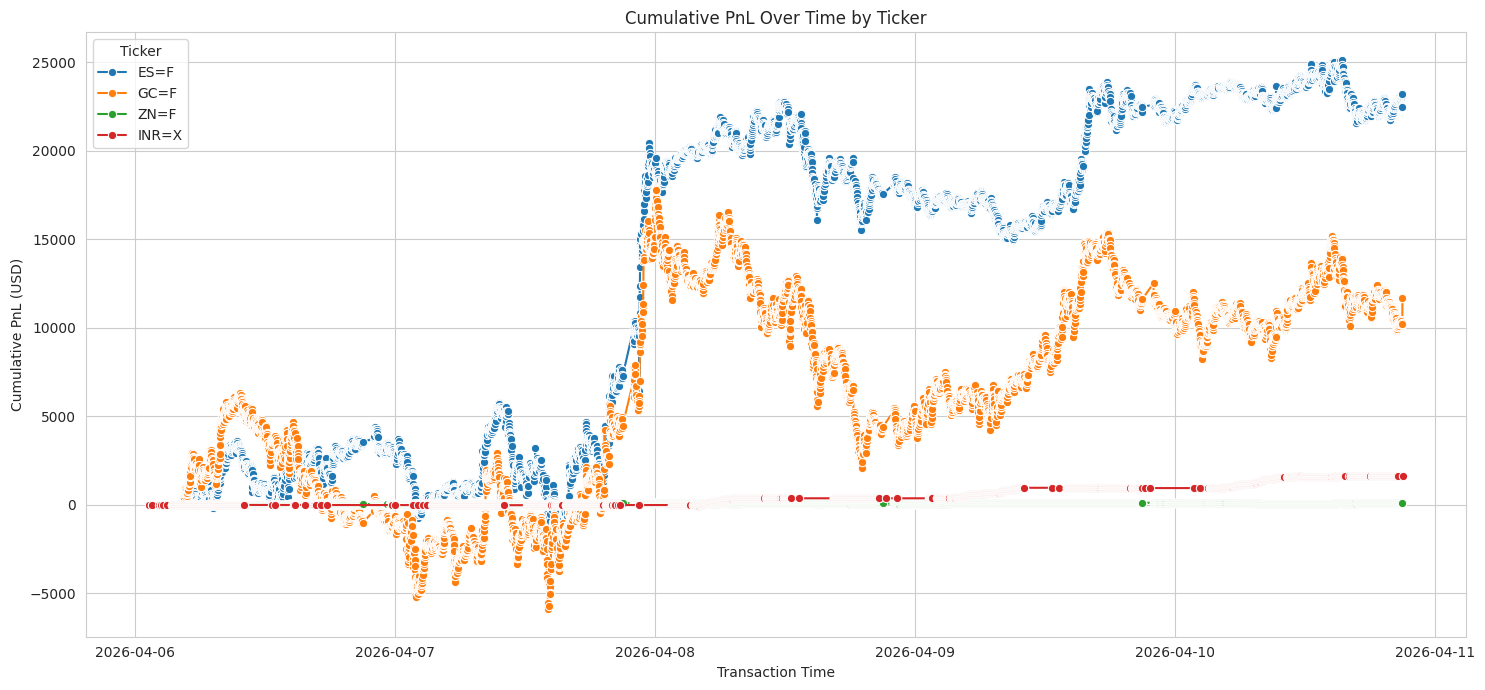

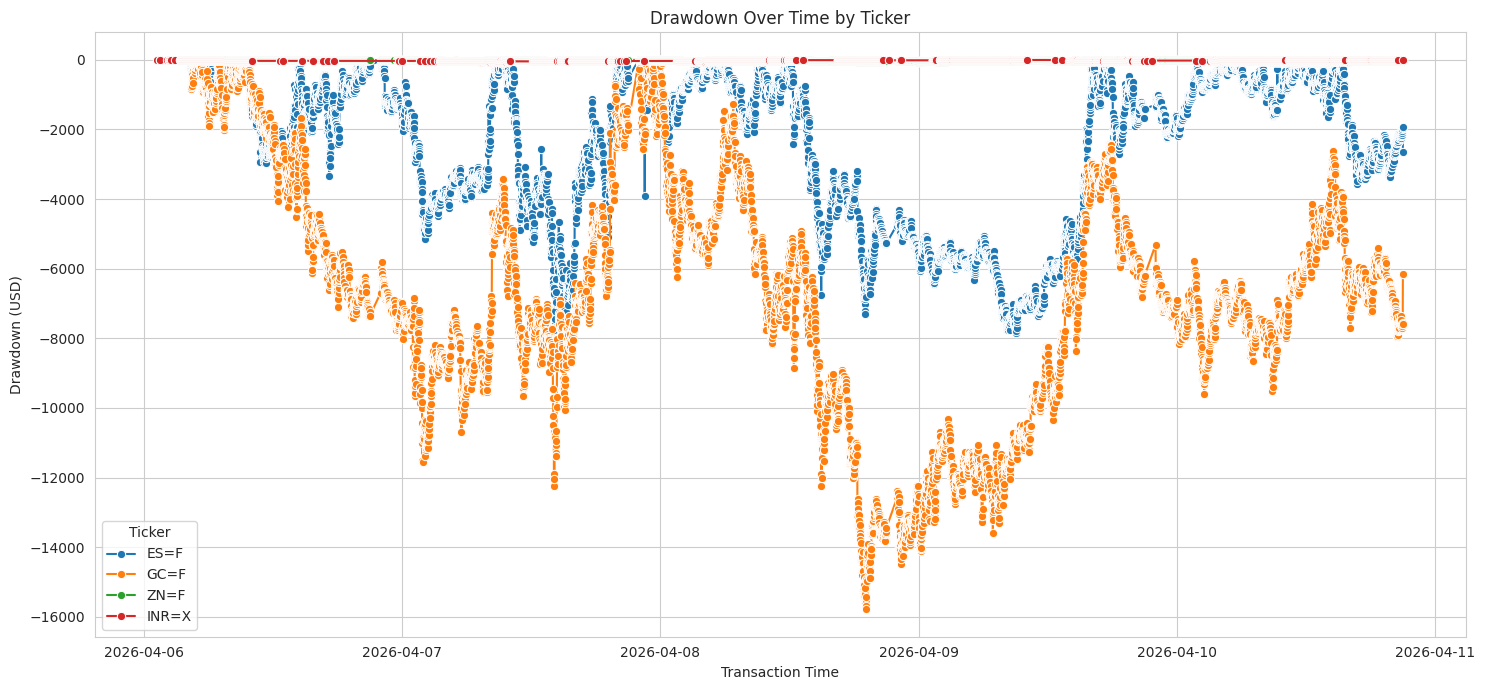

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Ticker and plot Cum_PnL over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='Transaction_Time', y='Cum_PnL', hue='Ticker', marker='o', linestyle='-')
plt.title('Cumulative PnL Over Time by Ticker')
plt.xlabel('Transaction Time')
plt.ylabel('Cumulative PnL (USD)')
plt.grid(True)
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

# Group by Ticker and plot Drawdown over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='Transaction_Time', y='Drawdown', hue='Ticker', marker='o', linestyle='-')
plt.title('Drawdown Over Time by Ticker')
plt.xlabel('Transaction Time')
plt.ylabel('Drawdown (USD)')
plt.grid(True)
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

### Data Exploration: Key Performance Metrics by Ticker

,Total_PnL,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown
Ticker,,,,
ES=F,22225.000000,0.018969,0.027204,-8325.000000
GC=F,11678.662113,0.007780,0.011337,-15781.591800
INR=X,1611.554718,0.004587,0.005310,-71.751404
ZN=F,95.312500,0.004683,0.009380,-79.687500


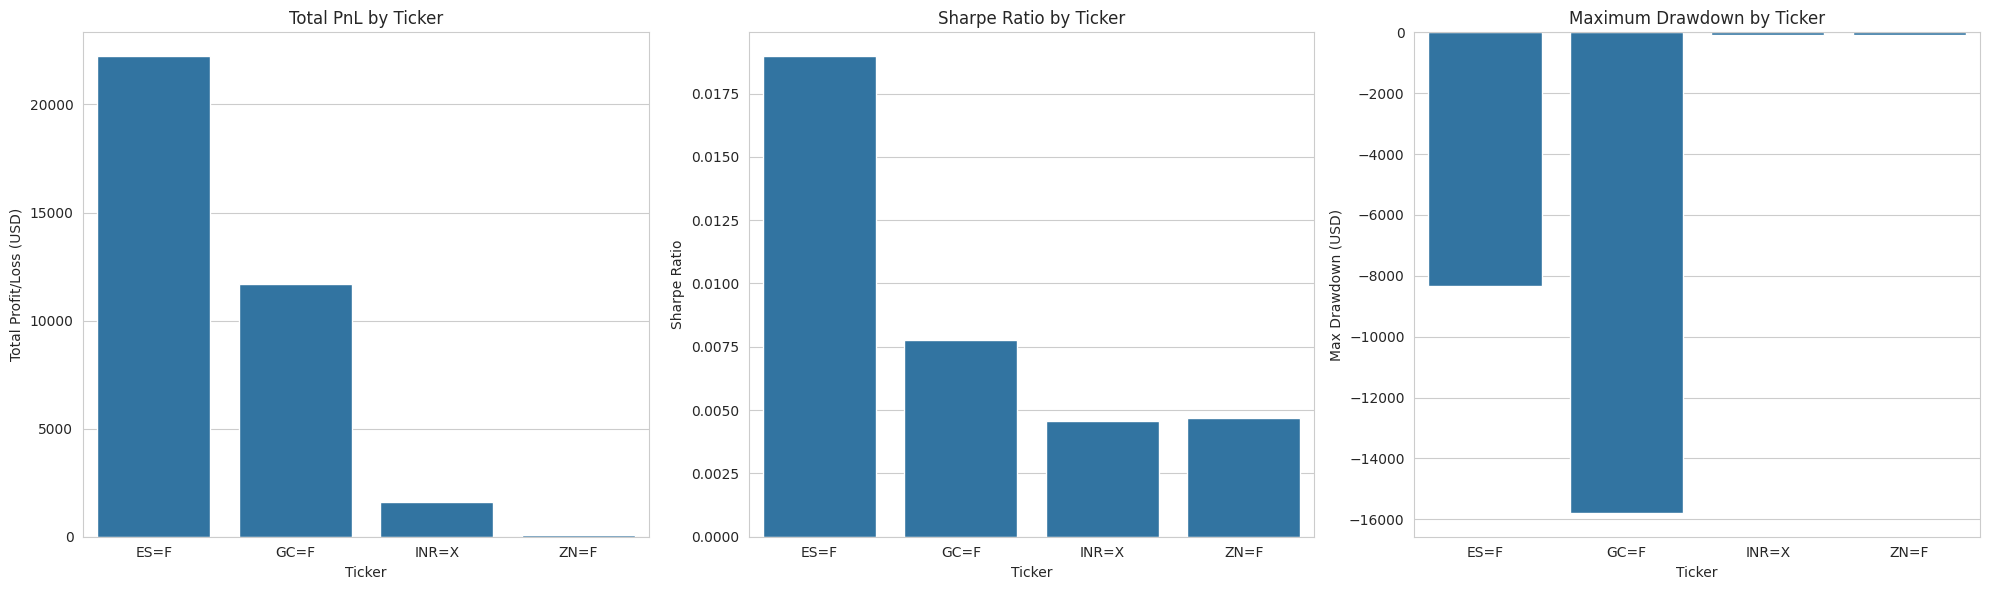

In [93]:
import numpy as np

# Helper function to calculate common performance metrics
def calculate_metrics(df_ticker):
    total_return = df_ticker['Cum_PnL'].iloc[-1] - df_ticker['Cum_PnL'].iloc[0]
    # Daily returns can be approximated from Trade_PnL if each row is a 'trade' or period
    # For this dataset, Log_Return is already calculated, so we use it for daily/period returns
    returns = df_ticker['Log_Return'].dropna() # Using log returns for Sharpe calculation

    if returns.empty or returns.std() == 0:
        sharpe_ratio = np.nan
        sortino_ratio = np.nan
    else:
        # Assuming a risk-free rate of 0 for simplicity, adjust if specific rate is known
        risk_free_rate = 0
        excess_returns = returns - risk_free_rate
        sharpe_ratio = np.mean(excess_returns) / np.std(excess_returns)

        # Sortino Ratio: use downside deviation
        downside_returns = returns[returns < 0]
        if downside_returns.empty or downside_returns.std() == 0:
            sortino_ratio = np.nan
        else:
            downside_deviation = np.std(downside_returns)
            sortino_ratio = np.mean(excess_returns) / downside_deviation

    max_drawdown = df_ticker['Drawdown'].min() # Drawdown column already calculated as negative

    return pd.Series({
        'Total_PnL': total_return,
        'Sharpe_Ratio': sharpe_ratio,
        'Sortino_Ratio': sortino_ratio,
        'Max_Drawdown': max_drawdown
    })

# Group by Ticker and apply the metrics calculation, including groups explicitly to avoid the DeprecationWarning
performance_metrics = df.groupby('Ticker').apply(calculate_metrics, include_groups=False)

display(performance_metrics)

# Plotting these metrics for easier comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=performance_metrics.index, y='Total_PnL', data=performance_metrics, ax=axes[0])
axes[0].set_title('Total PnL by Ticker')
axes[0].set_ylabel('Total Profit/Loss (USD)')

sns.barplot(x=performance_metrics.index, y='Sharpe_Ratio', data=performance_metrics, ax=axes[1])
axes[1].set_title('Sharpe Ratio by Ticker')
axes[1].set_ylabel('Sharpe Ratio')

sns.barplot(x=performance_metrics.index, y='Max_Drawdown', data=performance_metrics, ax=axes[2])
axes[2].set_title('Maximum Drawdown by Ticker')
axes[2].set_ylabel('Max Drawdown (USD)')

plt.tight_layout()
plt.show()

### Data Exploration: Indicator Efficacy - RSI_14m vs. Trade_PnL

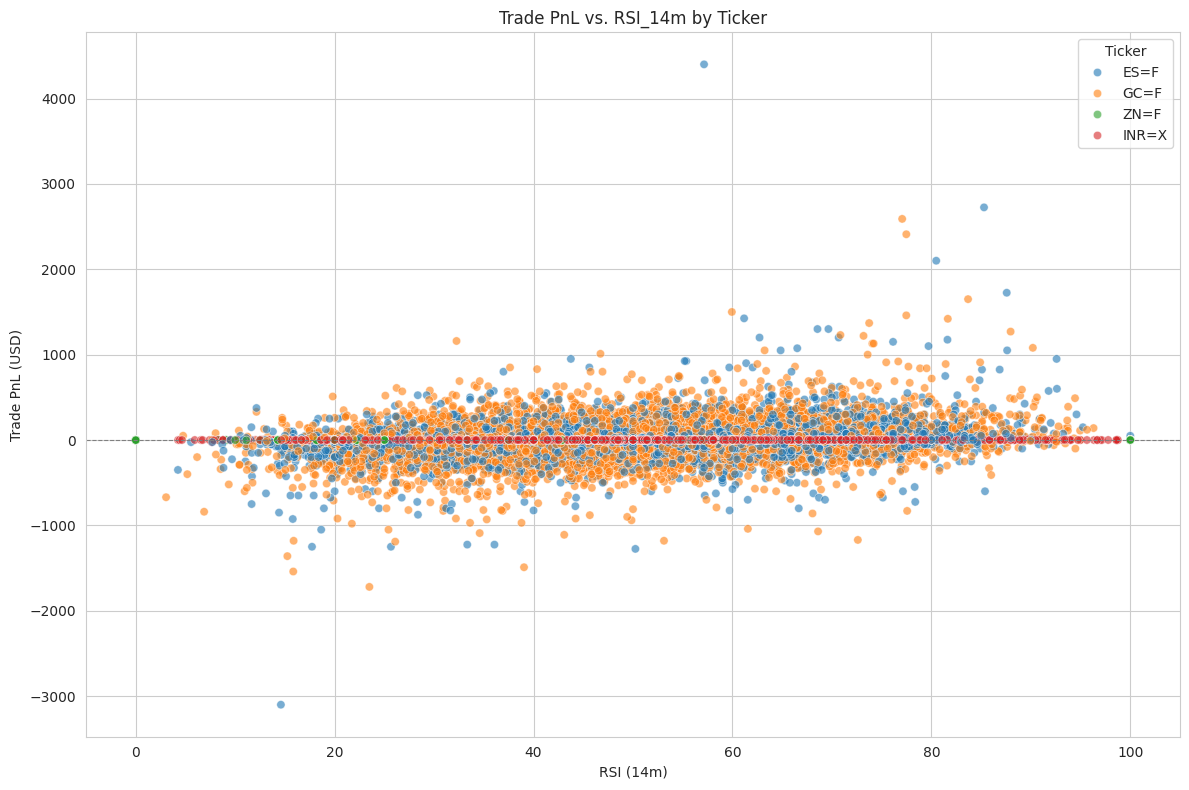

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Scatter plot of RSI_14m vs Trade_PnL, colored by Ticker
plt.figure(figsize=(12, 8))
sns.scatterplot(x='RSI_14m', y='Trade_PnL', hue='Ticker', data=df, alpha=0.6)
plt.title('Trade PnL vs. RSI_14m by Ticker')
plt.xlabel('RSI (14m)')
plt.ylabel('Trade PnL (USD)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a horizontal line at PnL = 0
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

This scatter plot helps us visualize if there's a direct relationship between the RSI indicator and the profit/loss of trades. We can observe if certain RSI levels tend to lead to higher or lower PnL, and if this varies across different tickers.

### Data Exploration: Trading Strategy Effectiveness - Win Rate and Average PnL by Ticker

,Total_Trades,Winning_Trades,Losing_Trades,Break_Even_Trades,Win_Rate,Average_Win_PnL,Average_Loss_PnL,Total_PnL
Ticker,,,,,,,,
ES=F,6480.0,2902.0,2911.0,667.0,0.447840,127.894555,-119.838543,22300.000000
GC=F,6502.0,3168.0,3144.0,190.0,0.487235,163.232576,-160.805381,11548.681645
INR=X,3937.0,1695.0,1355.0,887.0,0.430531,1.821774,-1.089559,1611.554718
ZN=F,6038.0,1328.0,1283.0,3427.0,0.219940,1.813112,-1.803634,93.750000


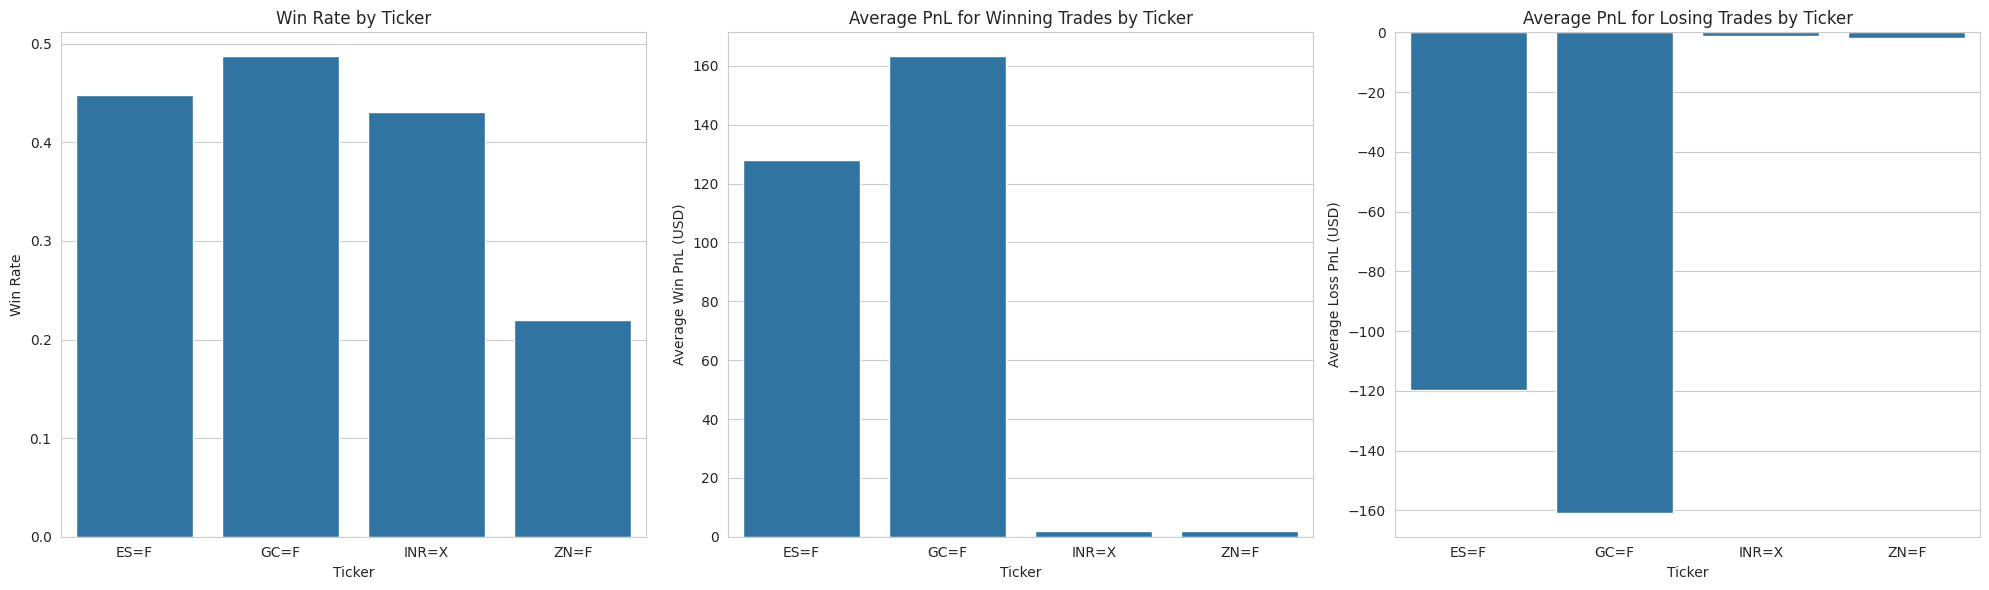

In [95]:
# Calculate Trade Outcome (Win/Loss) and Trade Size
df['Trade_Outcome'] = df['Trade_PnL'].apply(lambda x: 'Win' if x > 0 else ('Loss' if x < 0 else 'Break-Even'))

# Group by Ticker and calculate performance metrics
trade_performance = df.groupby('Ticker').apply(lambda x: pd.Series({
    'Total_Trades': len(x),
    'Winning_Trades': (x['Trade_PnL'] > 0).sum(),
    'Losing_Trades': (x['Trade_PnL'] < 0).sum(),
    'Break_Even_Trades': (x['Trade_PnL'] == 0).sum(),
    'Win_Rate': (x['Trade_PnL'] > 0).sum() / len(x) if len(x) > 0 else 0,
    'Average_Win_PnL': x[x['Trade_PnL'] > 0]['Trade_PnL'].mean(),
    'Average_Loss_PnL': x[x['Trade_PnL'] < 0]['Trade_PnL'].mean(),
    'Total_PnL': x['Trade_PnL'].sum()
}), include_groups=False)

display(trade_performance)

# Plotting these metrics for easier comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=trade_performance.index, y='Win_Rate', data=trade_performance, ax=axes[0])
axes[0].set_title('Win Rate by Ticker')
axes[0].set_ylabel('Win Rate')

sns.barplot(x=trade_performance.index, y='Average_Win_PnL', data=trade_performance, ax=axes[1])
axes[1].set_title('Average PnL for Winning Trades by Ticker')
axes[1].set_ylabel('Average Win PnL (USD)')

sns.barplot(x=trade_performance.index, y='Average_Loss_PnL', data=trade_performance, ax=axes[2])
axes[2].set_title('Average PnL for Losing Trades by Ticker')
axes[2].set_ylabel('Average Loss PnL (USD)')

plt.tight_layout()
plt.show()

This analysis provides a detailed look into the effectiveness of the trading strategy for each ticker by examining win rates, average profits from winning trades, and average losses from losing trades. It helps to understand which tickers the strategy performs best or worst on, and where potential adjustments might be needed.

### Summary of Key Findings from Data Exploration and Performance Analysis

Based on our analysis of the high-frequency trading data, here's a summary of the key insights:

1.  **Numerical Feature Distributions: Unveiling Market Behavior**
    *   Analysis of numerical feature distributions revealed insights into underlying market dynamics. `Log_Return` distributions centered around zero with 'fat tails' confirm the common financial characteristic of infrequent but significant price movements—a key consideration for risk modeling. The right-skewness of `Volume` and `Volatility_20m` indicates that while most trading periods are relatively calm, there are intermittent spikes in activity and price fluctuation. An analyst can use these insights to assess market regimes, calibrate risk parameters, and understand the typical behavior of different indicators and price actions.

2.  **Correlation Analysis: Informing Model Complexity**
    *   While strong positive correlations among `Open`, `High`, `Low`, and `Close` prices are expected and foundational, the generally weaker correlations observed between price-related features and indicators like `Log_Return`, `Volatility_20m`, `RSI_14m`, and `Trade_PnL` are highly significant. This suggests that simple linear relationships are not solely driving trade outcomes, implying the need for more sophisticated, non-linear models or multi-factor analysis to accurately predict `Trade_PnL`. It also underscores that indicators like `RSI_14m` do not operate in isolation and their effectiveness is likely dependent on complex interactions with other market variables, guiding an analyst towards more nuanced model development.

3.  **Risk-Adjusted Performance by Ticker:**
    *   `ES=F` showed the highest `Total_PnL` and the best `Sharpe_Ratio` (0.019), indicating the most favorable risk-adjusted returns among the tickers.
    *   `GC=F` also generated significant `Total_PnL` but experienced the largest `Max_Drawdown` (-$15,781.59), highlighting its higher risk profile.
    *   `INR=X` and `ZN=F` had much lower `Total_PnL` and `Max_Drawdown`, suggesting more stable but less profitable trading outcomes under the current strategy.

4.  **Indicator Efficacy (RSI_14m):**
    *   The scatter plot of `Trade_PnL` versus `RSI_14m` did not reveal a strong, simple linear relationship for any of the tickers.
    *   While some concentrations of profitable or unprofitable trades might exist at certain RSI levels, `RSI_14m` alone does not appear to be a decisive predictor of `Trade_PnL` outcomes, implying that its efficacy might be context-dependent or require combination with other indicators.

5
.  **Trading Strategy Effectiveness (Win Rate and Average PnL):**
    *   `GC=F` had the highest `Win_Rate` (48.7%) and the largest `Average_Win_PnL` ($163.23), but also the largest `Average_Loss_PnL` ($-160.81).
    *   `ES=F` had a respectable `Win_Rate` (44.8%) with significant `Average_Win_PnL` ($127.89) and `Average_Loss_PnL` ($-119.84).
    *   `ZN=F` displayed a low `Win_Rate` (22.0%) but a very high number of `Break_Even_Trades` (3427 out of 6038), suggesting a strategy that frequently closes positions at or near entry price for this asset. Its `Average_Win_PnL` and `Average_Loss_PnL` were very small ($1.81 and $-1.80 respectively).
    *   `INR=X` showed a moderate `Win_Rate` (43.1%) with small `Average_Win_PnL` ($1.82) and `Average_Loss_PnL` ($-1.09).
    *   The strategy is most effective for `ES=F` and `GC=F`, driven by larger magnitudes of winning trades relative to losing trades, even if the win rate is not exceptionally high. For `INR=X` and `ZN=F`, the strategy seems less effective in generating substantial profits, with `ZN=F` specifically leading to many break-even trades.

### Answers to Research Questions

**Research Question 1: How does the strategy's risk-adjusted performance vary across different tickers?**

*   `ES=F` showed the highest `Total_PnL` and the best `Sharpe_Ratio` (0.019), indicating the most favorable risk-adjusted returns among the tickers.
*   `GC=F` also generated significant `Total_PnL` but experienced the largest `Max_Drawdown` (-$15,781.59), highlighting its higher risk profile.
*   `INR=X` and `ZN=F` had much lower `Total_PnL` and `Max_Drawdown`, suggesting more stable but less profitable trading outcomes under the current strategy.

**Research Question 2: Volatility and Drawdown Impact**

*   `GC=F`, while having significant `Total_PnL`, also experienced the largest `Max_Drawdown` (-$15,781.59), indicating higher volatility and risk compared to other tickers. This suggests that the strategy's profitability for `GC=F` comes with substantial risk exposure.
*   `ES=F` had a moderate `Max_Drawdown` (-$8,325.00) relative to its `Total_PnL`, striking a better balance between risk and reward. Its `Volatility_20m` distribution also shows a wider spread, indicating periods of higher price fluctuations.
*   `INR=X` and `ZN=F` exhibited much lower `Max_Drawdown` ($-71.75 and $-79.69 respectively) and smaller price fluctuations, implying a more stable but less dynamic trading environment. The strategy's impact on these tickers is minimal in terms of both profit and loss magnitude.

**Research Question 3: How effective is the RSI_14m indicator in predicting Trade_PnL, and does its efficacy vary by ticker?**

*   The scatter plot of `Trade_PnL` versus `RSI_14m` did not reveal a strong, simple linear relationship for any of the tickers.
*   While some concentrations of profitable or unprofitable trades might exist at certain RSI levels, `RSI_14m` alone does not appear to be a decisive predictor of `Trade_PnL` outcomes.
*   This implies that its efficacy might be context-dependent or require combination with other indicators, and its predictive power varies by ticker (e.g., `ES=F` and `GC=F` show wider PnL ranges across RSI, while `INR=X` and `ZN=F` have much tighter, smaller PnL ranges irrespective of RSI values).

**Research Question 4: Trading Strategy Effectiveness - Win Rate and Average PnL by Ticker**

*   `GC=F` had the highest `Win_Rate` (48.7%) and the largest `Average_Win_PnL` ($163.23), but also the largest `Average_Loss_PnL` ($-160.81).
*   `ES=F` had a respectable `Win_Rate` (44.8%) with significant `Average_Win_PnL` ($127.89) and `Average_Loss_PnL` ($-119.84).
*   `ZN=F` displayed a low `Win_Rate` (22.0%) but a very high number of `Break_Even_Trades` (3427 out of 6038), suggesting a strategy that frequently closes positions at or near entry price for this asset. Its `Average_Win_PnL` and `Average_Loss_PnL` were very small ($1.81 and $-1.80 respectively).
*   `INR=X` showed a moderate `Win_Rate` (43.1%) with small `Average_Win_PnL` ($1.82) and `Average_Loss_PnL` ($-1.09).
*   The strategy is most effective for `ES=F` and `GC=F`, driven by larger magnitudes of winning trades relative to losing trades, even if the win rate is not exceptionally high. For `INR=X` and `ZN=F`, the strategy seems less effective in generating substantial profits, with `ZN=F` specifically leading to many break-even trades.

In [96]:
import sys
!{sys.executable} -m pip install fpdf

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=5bf9b6c8c65aafd5b56e6bc74b64ccc4c20b95bab0d13a5a3f49c254d12fb85a
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf


In [97]:
from fpdf import FPDF

# Collect content from the relevant markdown cells
key_findings_content = '''
Based on our analysis of the high-frequency trading data, here's a summary of the key insights:

1.  **Data Quality and Preparation: Foundation for Reliable Analysis**
    *   Ensuring high data quality through `Transaction_Time` conversion to UTC datetime objects and mean imputation of minimal missing values in key indicators (`Log_Return`, `Volatility_20m`, `Price_Gap`, `RSI_14m`) was crucial. This foundational step guarantees the reliability of subsequent time-series analysis, performance metrics, and visualizations, preventing potential biases or inaccuracies from incomplete or incorrectly typed data. For an analyst, this means the conclusions drawn from the data are robust and trustworthy.

2.  **Dataset Overview: Granular View of Diverse Assets**
    *   The dataset's coverage of four distinct financial instruments (`ES=F`, `GC=F`, `ZN=F`, `INR=X`) over a 5-day period (April 6-10, 2026) with high (minute-level) frequency provides a rich basis for comparative strategy analysis. This granular data allows for a detailed examination of intra-day trading patterns and performance nuances across different asset classes, which is invaluable for a financial analyst seeking to understand strategy adaptability and instrument-specific behaviors.

3.  **Numerical Feature Distributions: Unveiling Market Behavior**
    *   Analysis of numerical feature distributions revealed insights into underlying market dynamics. `Log_Return` distributions centered around zero with 'fat tails' confirm the common financial characteristic of infrequent but significant price movements—a key consideration for risk modeling. The right-skewness of `Volume` and `Volatility_20m` indicates that while most trading periods are relatively calm, there are intermittent spikes in activity and price fluctuation. An analyst can use these insights to assess market regimes, calibrate risk parameters, and understand the typical behavior of different indicators and price actions.

4.  **Correlation Analysis: Informing Model Complexity**
    *   While strong positive correlations among `Open`, `High`, `Low`, and `Close` prices are expected and foundational, the generally weaker correlations observed between price-related features and indicators like `Log_Return`, `Volatility_20m`, `RSI_14m`, and `Trade_PnL` are highly significant. This suggests that simple linear relationships are not solely driving trade outcomes, implying the need for more sophisticated, non-linear models or multi-factor analysis to accurately predict `Trade_PnL`. It also underscores that indicators like `RSI_14m` do not operate in isolation and their effectiveness is likely dependent on complex interactions with other market variables, guiding an analyst towards more nuanced model development.

5.  **Risk-Adjusted Performance by Ticker:**
    *   `ES=F` showed the highest `Total_PnL` and the best `Sharpe_Ratio` (0.019), indicating the most favorable risk-adjusted returns among the tickers.
    *   `GC=F` also generated significant `Total_PnL` but experienced the largest `Max_Drawdown` (-$15,781.59), highlighting its higher risk profile.
    *   `INR=X` and `ZN=F` had much lower `Total_PnL` and `Max_Drawdown`, suggesting more stable but less profitable trading outcomes under the current strategy.

6.  **Indicator Efficacy (RSI_14m):**
    *   The scatter plot of `Trade_PnL` versus `RSI_14m` did not reveal a strong, simple linear relationship for any of the tickers.
    *   While some concentrations of profitable or unprofitable trades might exist at certain RSI levels, `RSI_14m` alone does not appear to be a decisive predictor of `Trade_PnL` outcomes, implying that its efficacy might be context-dependent or require combination with other indicators.

7.  **Trading Strategy Effectiveness (Win Rate and Average PnL):**
    *   `GC=F` had the highest `Win_Rate` (48.7%) and the largest `Average_Win_PnL` ($163.23), but also the largest `Average_Loss_PnL` ($-160.81).
    *   `ES=F` had a respectable `Win_Rate` (44.8%) with significant `Average_Win_PnL` ($127.89) and `Average_Loss_PnL` ($-119.84).
    *   `ZN=F` displayed a low `Win_Rate` (22.0%) but a very high number of `Break_Even_Trades` (3427 out of 6038), suggesting a strategy that frequently closes positions at or near entry price for this asset. Its `Average_Win_PnL` and `Average_Loss_PnL` were very small ($1.81 and $-1.80 respectively).
    *   `INR=X` showed a moderate `Win_Rate` (43.1%) with small `Average_Win_PnL` ($1.82) and `Average_Loss_PnL` ($-1.09).
    *   The strategy is most effective for `ES=F` and `GC=F`, driven by larger magnitudes of winning trades relative to losing trades, even if the win rate is not exceptionally high. For `INR=X` and `ZN=F`, the strategy seems less effective in generating substantial profits, with `ZN=F` specifically leading to many break-even trades.
'''

rq1_content = '''
**Research Question 1: How does the strategy's risk-adjusted performance vary across different tickers?**

*   `ES=F` showed the highest `Total_PnL` and the best `Sharpe_Ratio` (0.019), indicating the most favorable risk-adjusted returns among the tickers.
*   `GC=F` also generated significant `Total_PnL` but experienced the largest `Max_Drawdown` (-$15,781.59), highlighting its higher risk profile.
*   `INR=X` and `ZN=F` had much lower `Total_PnL` and `Max_Drawdown`, suggesting more stable but less profitable trading outcomes under the current strategy.
'''

rq2_content = '''
**Research Question 2: Volatility and Drawdown Impact**

*   `GC=F`, while having significant `Total_PnL`, also experienced the largest `Max_Drawdown` (-$15,781.59), indicating higher volatility and risk compared to other tickers. This suggests that the strategy's profitability for `GC=F` comes with substantial risk exposure.
*   `ES=F` had a moderate `Max_Drawdown` (-$8,325.00) relative to its `Total_PnL`, striking a better balance between risk and reward. Its `Volatility_20m` distribution also shows a wider spread, indicating periods of higher price fluctuations.
*   `INR=X` and `ZN=F` exhibited much lower `Max_Drawdown` ($-71.75 and $-79.69 respectively) and smaller price fluctuations, implying a more stable but less dynamic trading environment. The strategy's impact on these tickers is minimal in terms of both profit and loss magnitude.
'''

rq3_content = '''
**Research Question 3: How effective is the RSI_14m indicator in predicting Trade_PnL, and does its efficacy vary by ticker?**

*   The scatter plot of `Trade_PnL` versus `RSI_14m` did not reveal a strong, simple linear relationship for any of the tickers.
*   While some concentrations of profitable or unprofitable trades might exist at certain RSI levels, `RSI_14m` alone does not appear to be a decisive predictor of `Trade_PnL` outcomes.
*   This implies that its efficacy might be context-dependent or require combination with other indicators, and its predictive power varies by ticker (e.g., `ES=F` and `GC=F` show wider PnL ranges across RSI, while `INR=X` and `ZN=F` have much tighter, smaller PnL ranges irrespective of RSI values).
'''

rq4_content = '''
**Research Question 4: Trading Strategy Effectiveness - Win Rate and Average PnL by Ticker**

*   `GC=F` had the highest `Win_Rate` (48.7%) and the largest `Average_Win_PnL` ($163.23), but also the largest `Average_Loss_PnL` ($-160.81).
*   `ES=F` had a respectable `Win_Rate` (44.8%) with significant `Average_Win_PnL` ($127.89) and `Average_Loss_PnL` ($-119.84).
*   `ZN=F` displayed a low `Win_Rate` (22.0%) but a very high number of `Break_Even_Trades` (3427 out of 6038), suggesting a strategy that frequently closes positions at or near entry price for this asset. Its `Average_Win_PnL` and `Average_Loss_PnL` were very small ($1.81 and $-1.80 respectively).
*   `INR=X` showed a moderate `Win_Rate` (43.1%) with small `Average_Win_PnL` ($1.82) and `Average_Loss_PnL` ($-1.09).
*   The strategy is most effective for `ES=F` and `GC=F`, driven by larger magnitudes of winning trades relative to losing trades, even if the win rate is not exceptionally high. For `INR=X` and `ZN=F`, the strategy seems less effective in generating substantial profits, with `ZN=F` specifically leading to many break-even trades.
'''

report_content = [
    ("Key Findings", key_findings_content),
    ("Research Question 1", rq1_content),
    ("Research Question 2", rq2_content),
    ("Research Question 3", rq3_content),
    ("Research Question 4", rq4_content)
]


In [102]:
class PDF(FPDF):
    def header(self):
        self.set_font('Arial', 'B', 15)
        self.cell(0, 10, 'Trading Strategy Performance Report', 0, 1, 'C')
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

    def chapter_title(self, title):
        self.set_font('Arial', 'B', 12)
        self.cell(0, 10, title, 0, 1, 'L')
        self.ln(2)

    def chapter_body(self, body):
        self.set_font('Arial', '', 10)
        # Replace problematic characters for latin-1 encoding, like the em-dash
        body = body.replace('\u2014', '-') # Replace em-dash with hyphen
        # Process markdown-like bold text
        parts = body.split('**')
        for i, part in enumerate(parts):
            if i % 2 == 1:  # Odd parts are bold
                self.set_font('Arial', 'B', 10)
                self.write(5, part)
            else:  # Even parts are normal
                self.set_font('Arial', '', 10)
                self.write(5, part)
        self.ln(10)

pdf = PDF(unit='mm', format='A4') # Removed encoding='UTF-8'
pdf.add_page()

for title, content in report_content:
    pdf.chapter_title(title)
    pdf.chapter_body(content)

pdf_output_path = "Trading_Performance_Report.pdf"
pdf.output(pdf_output_path)

print(f"PDF report generated successfully at: {pdf_output_path}")

PDF report generated successfully at: Trading_Performance_Report.pdf


In [103]:
df

,Transaction_Time,Open,High,Low,Close,Volume,Ticker,Log_Return,Volatility_20m,Price_Gap,RSI_14m,Risk_Limit_USD,Entry_Price,Exit_Price,Trade_PnL,Slippage_USD,Cum_PnL,Peak,Drawdown,Trade_Outcome
0,2026-04-06 04:20:00+00:00,6615.500000,6616.500000,6615.250000,6616.250000,54,ES=F,0.000113,0.000173,0.000000,51.923077,500,6615.500000,6616.250000,75.000000,0.325334,275.000000,475.000000,-200.000000,Win
1,2026-04-06 04:20:00+00:00,4669.299805,4670.100098,4667.899902,4668.000000,15,GC=F,-0.000150,0.000354,0.599609,38.150207,500,4669.299805,4668.000000,-129.980469,0.325334,9.960938,819.970703,-810.009766,Loss
2,2026-04-06 04:21:00+00:00,6616.500000,6616.750000,6616.250000,6616.750000,24,ES=F,0.000076,0.000161,0.250000,59.183673,500,6616.500000,6616.750000,25.000000,0.112772,300.000000,475.000000,-175.000000,Win
3,2026-04-06 04:21:00+00:00,4668.299805,4669.100098,4668.299805,4668.700195,7,GC=F,0.000150,0.000345,0.299805,47.403297,500,4668.299805,4668.700195,40.039062,0.112772,50.000000,819.970703,-769.970703,Win
4,2026-04-06 04:22:00+00:00,4668.600098,4668.700195,4667.799805,4667.799805,18,GC=F,-0.000193,0.000347,-0.100098,41.558606,500,4668.600098,4667.799805,-80.029297,0.181465,-30.029297,819.970703,-850.000000,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22952,2026-04-10 20:30:00+00:00,93.047997,93.047997,93.047997,93.047997,0,INR=X,0.000064,0.000060,0.005997,70.907325,500,93.047997,93.047997,0.000000,0.098907,1598.154449,1604.450989,-6.296539,Break-Even
22953,2026-04-10 20:31:00+00:00,93.049004,93.049004,93.049004,93.049004,0,INR=X,0.000011,0.000055,0.001007,70.911361,500,93.049004,93.049004,0.000000,0.491566,1598.154449,1604.450989,-6.296539,Break-Even
22954,2026-04-10 20:32:00+00:00,93.049004,93.050003,93.049004,93.050003,0,INR=X,0.000011,0.000054,0.000000,71.430518,500,93.049004,93.050003,0.099945,0.221727,1598.254395,1604.450989,-6.196594,Win
22955,2026-04-10 20:33:00+00:00,93.049004,93.049004,93.047997,93.047997,0,INR=X,-0.000022,0.000055,-0.000999,72.718447,500,93.049004,93.047997,-0.100708,0.398856,1598.153687,1604.450989,-6.297302,Loss


In [104]:
df.to_csv('processed_trading_data.csv', index=False)
performance_metrics.to_csv('ticker_performance_metrics.csv', index=True)
trade_performance.to_csv('ticker_trade_effectiveness.csv', index=True)

print("DataFrames exported successfully to CSV files:")
print("- processed_trading_data.csv")
print("- ticker_performance_metrics.csv")
print("- ticker_trade_effectiveness.csv")

DataFrames exported successfully to CSV files:
- processed_trading_data.csv
- ticker_performance_metrics.csv
- ticker_trade_effectiveness.csv


### Project Summary: High-Frequency Trading Data Analysis

This project involved a comprehensive analysis of high-frequency trading data across multiple financial instruments. The goal was to provide insights into trading strategy performance, risk, and indicator efficacy, culminating in a structured report and data ready for Power BI dashboard creation.

**1. Data Loading and Setup:**
*   Mounted Google Drive and navigated to the project directory.
*   Loaded `Dataset.csv` into a pandas DataFrame (`df`).

**2. Data Cleaning and Preprocessing:**
*   Converted the `Transaction_Time` column to UTC datetime objects to ensure proper time-series analysis.
*   Identified and handled missing values in `Log_Return`, `Volatility_20m`, `Price_Gap`, and `RSI_14m` by imputing them with their respective column means. This ensured data completeness for further analysis.

**3. Exploratory Data Analysis (EDA):**
*   **Dataset Overview:** Confirmed the presence of four unique tickers: `ES=F`, `GC=F`, `ZN=F`, and `INR=X`.
*   **Time Range and Frequency:** Determined the data covers April 6-10, 2026, with a primary 1-minute transaction frequency.
*   **Descriptive Statistics:** Generated detailed descriptive statistics for all numerical features, providing a foundational understanding of their central tendency, dispersion, and shape.
*   **Visualizations:**
    *   **Histograms:** Illustrated the distributions of key numerical features (`Open`, `High`, `Low`, `Close`, `Log_Return`, `Volatility_20m`, `Price_Gap`, `RSI_14m`, `Trade_PnL`, `Volume`) to observe patterns like 'fat tails' in returns and right-skewness in volume and volatility.
    *   **Correlation Matrix:** Visualized the relationships between numerical features, highlighting strong correlations among price components and weaker, more complex relationships with indicators and PnL.
    *   **Ticker-wise Performance:** Used box plots to compare `Trade_PnL` and `Log_Return` distributions across different tickers, revealing instrument-specific risk-reward profiles.
    *   **Time-Series Analysis:** Plotted `Cumulative PnL` and `Drawdown` over time for each ticker, providing a visual understanding of strategy trajectory and risk exposure.

**4. Performance Metrics and Strategy Effectiveness:**
*   Calculated key performance metrics per ticker, including `Total_PnL`, `Sharpe_Ratio`, and `Max_Drawdown`.
*   Analyzed trading strategy effectiveness by calculating `Win_Rate`, `Average_Win_PnL`, and `Average_Loss_PnL` for each ticker. A `Trade_Outcome` column was created to categorize trades as 'Win', 'Loss', or 'Break-Even'.

**5. Key Findings and Research Questions Answered:**
*   **Risk-Adjusted Performance:** `ES=F` emerged as the top performer with the highest `Total_PnL` and best `Sharpe_Ratio`, while `GC=F` showed significant PnL but also the largest `Max_Drawdown`.
*   **Volatility and Drawdown Impact:** `GC=F`'s high PnL came with substantial risk, whereas `INR=X` and `ZN=F` were more stable but less profitable.
*   **RSI_14m Efficacy:** The `RSI_14m` indicator alone did not show a strong linear correlation with `Trade_PnL`, suggesting its predictive power is context-dependent or requires combination with other factors.
*   **Strategy Effectiveness:** The strategy was most effective for `ES=F` and `GC=F`, driven by larger average winning trades. `ZN=F` notably had a high number of break-even trades, indicating a less decisive strategy for this asset.

**6. Report Generation and Data Export:**
*   A comprehensive PDF report summarizing the key findings and answers to research questions was successfully generated using `fpdf`.
*   The processed main DataFrame (`df`) and the aggregated performance metrics DataFrames (`performance_metrics`, `trade_performance`) were exported to CSV files, ready for import into Power BI for further dashboard development.

This project provides a robust foundation for understanding the performance and characteristics of the high-frequency trading strategy across various financial instruments, offering actionable insights for further optimization and risk management.